# 📘Домашнє завдання №14 Boosting

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW14

# Частина 1. Класифікація

---

## 📌 Завдання 1. Класифікація (Titanic)

Використайте датасет Titanic:  
https://www.kaggle.com/datasets/yasserh/titanic-dataset  

### Необхідно:
- Завантажити дані
- Провести базовий аналіз:
  - розмір датасету
  - типи змінних
  - кількість пропусків
- Обробити пропущені значення
- Видалити неінформативні колонки (наприклад: `Name`, `Ticket`, `Cabin`, якщо вважаєте за потрібне)
- Обробити категоріальні змінні:
  - для **XGBoost** → використати `OneHotEncoding`
  - для **LightGBM** → використати native categorical features
  - для **CatBoost** → використати native categorical features

### Цільова змінна:
`Survived`

---

## 📌 Завдання 2. Побудова моделей класифікації

Побудуйте **три моделі**:

- `XGBClassifier`
- `LGBMClassifier`
- `CatBoostClassifier`

### Для кожної моделі:
- натренуйте модель
- зробіть прогноз
- обчисліть метрики:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC

---

### Порівняйте результати моделей

Створіть таблицю такого формату:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|------------|------------|--------|-----|----------|
| XGBoost | ? | ? | ? | ? | ? |
| LightGBM | ? | ? | ? | ? | ? |
| CatBoost | ? | ? | ? | ? | ? |

---

### Проаналізуйте:
- яка модель показала найкращий результат
- чи достатньо accuracy для задачі Titanic
- яка модель найзручніша в роботі з категоріальними змінними

---

## 📌 Завдання 3. Feature Importance (класифікація)

Для кожної моделі:

- отримайте важливість ознак
- побудуйте графік feature importance

### Проаналізуйте:
- які ознаки найважливіші
- чи співпадає це з інтуїцією:
  - `Sex`
  - `Pclass`
  - `Age`
  - `Fare`

---

# Частина 2. Регресія

---

## 📌 Завдання 4. Регресія (Fish Market)

Використайте датасет Fish Market:  
https://www.kaggle.com/datasets/vipullrathod/fish-market  

### Цільова змінна:
`Weight`

---

### Попередня обробка:
- дослідити дані
- перевірити пропуски
- обробити категоріальну змінну `Species`

### Для моделей:
- **XGBoost** → OneHotEncoding
- **LightGBM** → native categorical features
- **CatBoost** → native categorical features

---

## 📌 Завдання 5. Побудова моделей регресії

Побудуйте:

- `XGBRegressor`
- `LGBMRegressor`
- `CatBoostRegressor`

### Для кожної моделі:
- натренуйте модель
- зробіть прогноз
- обчисліть метрики:
  - MAE
  - MSE
  - RMSE
  - R²

---

### Порівняйте результати моделей

Створіть таблицю такого формату:

| Model | MAE | MSE | RMSE | R² |
|--------|------|------|------|------|
| XGBoost | ? | ? | ? | ? |
| LightGBM | ? | ? | ? | ? |
| CatBoost | ? | ? | ? | ? |

---

### Проаналізуйте:
- яка модель працює найкраще
- чи вплинула обробка категоріальних змінних на результат
- яка модель найпростіша у використанні

---

## 📌 Завдання 6. Feature Importance (регресія)

Для кожної моделі:

- отримайте feature importance
- побудуйте графіки

### Проаналізуйте:
- які характеристики риби найбільше впливають на вагу:
  - `Length`
  - `Height`
  - `Width`
  - `Species`

In [1]:
from numpy.f2py.crackfortran import verbose

# Silent installation or update

package_array = [
    "pip",
    "jinja2",
    "ipywidgets",
    "nbformat",
    "kagglehub[pandas-datasets]",
]

# !python3 -m pip install --upgrade pip -q
for package_name in package_array:
    # !bash -c "echo '{package_name}'"
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install --upgrade '{package_name}' -q"


In [2]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input data
git_project_url = "https://github.com/BogdanPinchuk/DataScience-PBY_HW14.git"
main_file_name = "Bohdan_Pinchuk_DS_HW14.ipynb"

# Solution

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone data
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Cloning into '/Users/bohdanpinchuk/Documents/Data Science/Development/Data_Science/Practical_tasks/Homework_14/temp'...
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 163 (delta 78), reused 127 (delta 42), pack-reused 0 (from 0)
Receiving objects: 100% (163/163), 1.05 MiB | 5.31 MiB/s, done.
Resolving deltas: 100% (78/78), done.


In [3]:
# Downloading data

import apps.main as mn

# Input data
update_db = False
db_file_name = "resources/store_hw14.db"

# Solution
titanic_dataset = mn.download_and_extract_from_kagglehub("yasserh/titanic-dataset", "Titanic-Dataset.csv",
                                                         db_file_name, update_db)
fish_market = mn.download_and_extract_from_kagglehub("vipullrathod/fish-market", "Fish.csv",
                                                     db_file_name, update_db)

# Print result
# display(titanic_dataset, fish_market)


## ✅ Рішення 1

Використайте датасет Titanic.

Необхідно:
- Завантажити дані
- Провести базовий аналіз:
  - розмір датасету
  - типи змінних
  - кількість пропусків
- Обробити пропущені значення
- Видалити неінформативні колонки (наприклад: `Name`, `Ticket`, `Cabin`, якщо вважаєте за потрібне)
- Обробити категоріальні змінні:
  - для **XGBoost** → використати `OneHotEncoding`
  - для **LightGBM** → використати native categorical features
  - для **CatBoost** → використати native categorical features

Цільова змінна: `Survived`

In [4]:
# Data analysis

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.core.display import Markdown

# Input data
data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

# Solution
columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Аналіз даних"))
rp.print_pd_report("Параметри таблиці до обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))

display(data_set)

### Аналіз даних

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,12
Кількість числових ознак,7
Кількість категоріальних ознак,5
Пропущені значення,є


,count
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


,Types
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
# Data preparation

import numpy as np
import pandas as pd
import apps.reporter as rpt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from IPython.core.display import Markdown

# Input data
fil_num_col_list = ["Age"]
fil_cat_col_list = ["Embarked"]
cat_col_list = ["Sex"]
pd.options.display.float_format = "{:g}".format

# Solution
preprocessor = ColumnTransformer([
    ("fil_num", SimpleImputer(strategy="median"), fil_num_col_list),
    ("fil_cat", SimpleImputer(strategy="most_frequent"), fil_cat_col_list),
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")
transformed_data = preprocessor.fit_transform(titanic_dataset)
titanic_dataset = pd.DataFrame(transformed_data, columns=preprocessor.get_feature_names_out())

data_set = titanic_dataset
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Підготовка даних (titanic_dataset)"))
rp.print_pd_report("Параметри таблиці без кодування")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))
display(data_set)

### Підготовка даних (titanic_dataset)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,12
Кількість числових ознак,7
Кількість категоріальних ознак,5
Пропущені значення,є


,count
Age,0
Embarked,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
SibSp,0
Parch,0
Ticket,0


,Types
Age,float64
Embarked,str
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
SibSp,int64
Parch,int64
Ticket,str


,Age,Embarked,PassengerId,Survived,Pclass,Name,Sex,SibSp,Parch,Ticket,Fare,Cabin
0,22,S,1,0,3,"Braund, Mr. Owen Harris",male,1,0,A/5 21171,7.25,NaN
1,38,C,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,1,0,PC 17599,71.2833,C85
2,26,S,3,1,3,"Heikkinen, Miss. Laina",female,0,0,STON/O2. 3101282,7.925,NaN
3,35,S,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,1,0,113803,53.1,C123
4,35,S,5,0,3,"Allen, Mr. William Henry",male,0,0,373450,8.05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
886,27,S,887,0,2,"Montvila, Rev. Juozas",male,0,0,211536,13,NaN
887,19,S,888,1,1,"Graham, Miss. Margaret Edith",female,0,0,112053,30,B42
888,28,S,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,2,W./C. 6607,23.45,NaN
889,26,C,890,1,1,"Behr, Mr. Karl Howell",male,0,0,111369,30,C148


In [6]:
# Data preparation

import numpy as np
import pandas as pd
import apps.reporter as rpt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from IPython.core.display import Markdown

# Input data
fil_num_col_list = ["Age"]
fil_cat_col_list = ["Embarked"]
cat_col_list = ["Sex"]
pd.options.display.float_format = "{:g}".format

# Solution
cat_pipeline = Pipeline([
    ("fil_cat", SimpleImputer(strategy="most_frequent")),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype="int64")),
])
# need to remove original column

preprocessor = ColumnTransformer([
    ("fil_num", SimpleImputer(strategy="median"), fil_num_col_list),
    ("pipe_cat", cat_pipeline, fil_cat_col_list),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype="int64"), cat_col_list),
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")
transformed_data = preprocessor.fit_transform(titanic_dataset)
titanic_dataset_ohe = pd.DataFrame(transformed_data, columns=preprocessor.get_feature_names_out())

data_set = titanic_dataset_ohe
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Підготовка даних (titanic_dataset_ohe)"))
rp.print_pd_report("Параметри таблиці з кодуванням")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))
display(data_set)

### Підготовка даних (titanic_dataset_ohe)

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,15
Кількість числових ознак,12
Кількість категоріальних ознак,3
Пропущені значення,є


,count
Age,0
Embarked_C,0
Embarked_Q,0
Embarked_S,0
Sex_female,0
Sex_male,0
PassengerId,0
Survived,0
Pclass,0
Name,0


,Types
Age,float64
Embarked_C,int64
Embarked_Q,int64
Embarked_S,int64
Sex_female,int64
Sex_male,int64
PassengerId,int64
Survived,int64
Pclass,int64
Name,str


,Age,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,PassengerId,Survived,Pclass,Name,SibSp,Parch,Ticket,Fare,Cabin
0,22,0,0,1,0,1,1,0,3,"Braund, Mr. Owen Harris",1,0,A/5 21171,7.25,NaN
1,38,1,0,0,1,0,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",1,0,PC 17599,71.2833,C85
2,26,0,0,1,1,0,3,1,3,"Heikkinen, Miss. Laina",0,0,STON/O2. 3101282,7.925,NaN
3,35,0,0,1,1,0,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,113803,53.1,C123
4,35,0,0,1,0,1,5,0,3,"Allen, Mr. William Henry",0,0,373450,8.05,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,27,0,0,1,0,1,887,0,2,"Montvila, Rev. Juozas",0,0,211536,13,NaN
887,19,0,0,1,1,0,888,1,1,"Graham, Miss. Margaret Edith",0,0,112053,30,B42
888,28,0,0,1,1,0,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,2,W./C. 6607,23.45,NaN
889,26,1,0,0,0,1,890,1,1,"Behr, Mr. Karl Howell",0,0,111369,30,C148


In [7]:
# Data cleaning

import gc
import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.core.display import Markdown

# Input data
ages_col_name = "Age"
fares_col_name = "Fare"
sibsp_col_name = "SibSp"
parch_col_name = "Parch"
family_col_name = "Family"
drop_col_list = ["PassengerId", "Name", "Ticket", "Cabin"]

# Solution
titanics = [titanic_dataset, titanic_dataset_ohe]
titles = ["Датасет без кодування: (titanic_dataset)", "Датасет з кодуванням: (titanic_dataset_ohe)"]

display(Markdown(f"### Очищення даних"))

for idx, titanic in enumerate(titanics):
    titanic.drop(columns=drop_col_list, inplace=True)

    # Корегування даних
    titanic[ages_col_name] = titanic[ages_col_name].round().astype(int)
    titanic[fares_col_name] = titanic[fares_col_name].round(2).astype(float)

    # Заміна даних і очищення
    titanic[family_col_name] = (titanic.apply(lambda df_row: df_row[sibsp_col_name] + df_row[parch_col_name] + 1,
                                              axis=1).astype(int))
    titanic.drop(columns=[sibsp_col_name, parch_col_name], inplace=True)

    data_set = titanic
    n_columns = data_set.columns.size
    n_rows = data_set.index.size

    columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
    types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

    col_num_type = data_set.select_dtypes(include=np.number).columns
    col_cat_type = data_set.select_dtypes(exclude=np.number).columns

    empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
    is_empty_val = empty_val_by_col.values.sum() > 0

    rp = rpt.Reporter()
    rp.add_item("Кількість рядків", str(n_rows))
    rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
    rp.add_item("Кількість стовпців", str(n_columns))
    rp.add_item("Кількість числових ознак", str(col_num_type.size))
    rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
    rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

    # Print results
    display(Markdown(f"**{titles[idx]}**"))

    rp.print_pd_report("Параметри таблиці після очищення")

    if is_empty_val > 0:
        display(empty_val_by_col.style.set_caption("Кількість пропусків"))
    display(types_df.style.set_caption("Типи даних"))

    display(data_set)

del titanics

_ = gc.collect()

### Очищення даних

**Датасет без кодування: (titanic_dataset)**

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,7
Кількість числових ознак,5
Кількість категоріальних ознак,2
Пропущені значення,немає


,Types
Age,int64
Embarked,str
Survived,int64
Pclass,int64
Sex,str
Fare,float64
Family,int64


,Age,Embarked,Survived,Pclass,Sex,Fare,Family
0,22,S,0,3,male,7.25,2
1,38,C,1,1,female,71.28,2
2,26,S,1,3,female,7.92,1
3,35,S,1,1,female,53.1,2
4,35,S,0,3,male,8.05,1
...,...,...,...,...,...,...,...
886,27,S,0,2,male,13,1
887,19,S,1,1,female,30,1
888,28,S,0,3,female,23.45,4
889,26,C,1,1,male,30,1


**Датасет з кодуванням: (titanic_dataset_ohe)**

Attribute,Result
Кількість рядків,891
Кількість об’єктів у датасеті,891
Кількість стовпців,10
Кількість числових ознак,10
Кількість категоріальних ознак,0
Пропущені значення,немає


,Types
Age,int64
Embarked_C,int64
Embarked_Q,int64
Embarked_S,int64
Sex_female,int64
Sex_male,int64
Survived,int64
Pclass,int64
Fare,float64
Family,int64


,Age,Embarked_C,Embarked_Q,Embarked_S,Sex_female,Sex_male,Survived,Pclass,Fare,Family
0,22,0,0,1,0,1,0,3,7.25,2
1,38,1,0,0,1,0,1,1,71.28,2
2,26,0,0,1,1,0,1,3,7.92,1
3,35,0,0,1,1,0,1,1,53.1,2
4,35,0,0,1,0,1,0,3,8.05,1
...,...,...,...,...,...,...,...,...,...,...
886,27,0,0,1,0,1,0,2,13,1
887,19,0,0,1,1,0,1,1,30,1
888,28,0,0,1,1,0,0,3,23.45,4
889,26,1,0,0,0,1,1,1,30,1


In [8]:
# Splitting data

import gc
import pandas as pd
from sklearn.model_selection import train_test_split

# Input data
target_value = "Survived"
test_ratio = 0.2
rng_seed = 42

# Solution
X_data_ohe = titanic_dataset_ohe.drop(columns=[target_value])
Y_data_ohe = titanic_dataset_ohe[target_value]
X_data = titanic_dataset.drop(columns=[target_value])
Y_data = titanic_dataset[target_value]

col_cat_type = X_data.select_dtypes(exclude=np.number).columns.tolist()
for col_name in col_cat_type:
    X_data[col_name] = X_data[col_name].astype('category')

cat_type_df = X_data[col_cat_type]

del titanic_dataset, titanic_dataset_ohe

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data,
                                                    test_size=test_ratio,
                                                    stratify=Y_data,
                                                    random_state=rng_seed,
                                                    shuffle=True)

X_train_ohe, X_test_ohe, Y_train_ohe, Y_test_ohe = train_test_split(X_data_ohe, Y_data_ohe,
                                                                    test_size=test_ratio,
                                                                    stratify=Y_data_ohe,
                                                                    random_state=rng_seed,
                                                                    shuffle=True)

# Print results
display(Markdown(f"### Розбиття даних"))

display(cat_type_df.describe().T.style.set_caption("Статистика для категоріальних змінних"))

for col_name in col_cat_type:
    display(pd.concat([
        cat_type_df[col_name].value_counts(),
        cat_type_df[col_name].value_counts(normalize=True)
    ], axis=1).style.set_caption(f"Категорія: \"{col_name}\""))

display(Markdown(f"**Датасет без кодування: (titanic_dataset)**"))
display(pd.concat([
    Y_train.value_counts(),
    Y_train.value_counts(normalize=True)
], axis=1).style.format_index("{:g}").set_caption("Вибірка для навчання"))
display(pd.concat([
    Y_test.value_counts(),
    Y_test.value_counts(normalize=True)
], axis=1).style.format_index("{:g}").set_caption("Вибірка для тестування"))

display(Markdown(f"**Датасет з кодуванням: (titanic_dataset_ohe)**"))
display(pd.concat([
    Y_train_ohe.value_counts(),
    Y_train_ohe.value_counts(normalize=True)
], axis=1).style.format_index("{:g}").set_caption("Вибірка для навчання"))
display(pd.concat([
    Y_test_ohe.value_counts(),
    Y_test_ohe.value_counts(normalize=True)
], axis=1).style.format_index("{:g}").set_caption("Вибірка для тестування"))

# Clean
_ = gc.collect()

### Розбиття даних

,count,unique,top,freq
Embarked,891,3,S,646
Sex,891,2,male,577


,count,proportion
Embarked,,
S,646,0.725028
C,168,0.188552
Q,77,0.086420


,count,proportion
Sex,,
male,577,0.647587
female,314,0.352413


**Датасет без кодування: (titanic_dataset)**

,count,proportion
Survived,,
0,439,0.616573
1,273,0.383427


,count,proportion
Survived,,
0,110,0.614525
1,69,0.385475


**Датасет з кодуванням: (titanic_dataset_ohe)**

,count,proportion
Survived,,
0,439,0.616573
1,273,0.383427


,count,proportion
Survived,,
0,110,0.614525
1,69,0.385475


## ✅ Рішення 2-3

Побудуйте **три моделі**:

- `XGBClassifier`
- `LGBMClassifier`
- `CatBoostClassifier`

Для кожної моделі:
- натренуйте модель
- зробіть прогноз
- обчисліть метрики:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC

---

Порівняйте результати моделей

Створіть таблицю такого формату:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|------------|------------|--------|-----|----------|
| XGBoost | ? | ? | ? | ? | ? |
| LightGBM | ? | ? | ? | ? | ? |
| CatBoost | ? | ? | ? | ? | ? |

---

Проаналізуйте:
- яка модель показала найкращий результат
- чи достатньо accuracy для задачі Titanic
- яка модель найзручніша в роботі з категоріальними змінними

---

Для кожної моделі:

- отримайте важливість ознак
- побудуйте графік feature importance

### Проаналізуйте:
- які ознаки найважливіші
- чи співпадає це з інтуїцією:
  - `Sex`
  - `Pclass`
  - `Age`
  - `Fare`


In [9]:
# XGBoost

import joblib
import apps.main as mn
from pathlib import Path
from xgboost import XGBClassifier

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset_xgboost_c.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        random_state=rng_seed,
        eval_metric='logloss',
        n_jobs=-1
    )
    model.fit(X_train_ohe, Y_train_ohe, verbose=0)
    # save model
    joblib.dump(model, model_file_name)

Y_pred_xgboost = model.predict(X_test_ohe)
Y_prob_xgboost = model.predict_proba(X_test_ohe)[:, 1]

# Print results
display(Markdown(f"### XGBoost"))
df_xgboost_c = mn.calc_class_metrics(Y_test_ohe, Y_pred_xgboost, Y_prob_xgboost)


### XGBoost

Attribute,Result
Confusion Matrix,[[99 11] [24 45]]
Accuracy (Точність),0.8045
Precision (Влучність),0.8036
Recall (Повнота),0.6522
F1-score,0.7200
Receiver Operating Characteristic (ROC-AUC),0.8394
Average Precision (AP),0.8179


              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179



In [10]:
import numpy as np
import pandas as pd

# Input data

# Solution
features = X_data_ohe.columns
feature_importances = model.feature_importances_ / model.feature_importances_.sum()
feature_importances_cum = np.cumsum(feature_importances)

importances_df = (pd.DataFrame({"feature": features, "importance": feature_importances}).
                  sort_values(by="importance", ascending=False, ignore_index=True))

# Print results
display(importances_df.style.set_caption("Feature Importances"))

,feature,importance
0,Sex_female,0.648849
1,Pclass,0.169266
2,Family,0.040197
3,Embarked_S,0.040115
4,Age,0.037447
5,Fare,0.035051
6,Embarked_C,0.018932
7,Embarked_Q,0.010143
8,Sex_male,0.000000


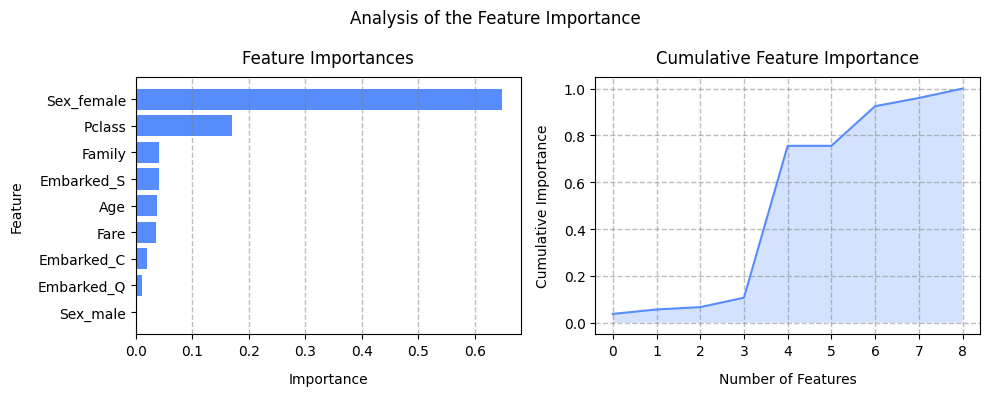

In [11]:
# Graphic results

import numpy as np
import matplotlib.pyplot as plt

# Input data
x_axis = np.arange(len(feature_importances_cum))

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.barh(importances_df["feature"], importances_df["importance"])
ax.invert_yaxis()
ax.grid(axis='x', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Feature Importances", pad=10, loc='center', color='black')
ax.set_xlabel("Importance", labelpad=10, loc='center', color='black')
ax.set_ylabel("Feature", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.plot(x_axis, feature_importances_cum)
ax.fill_between(x_axis, feature_importances_cum, alpha=0.25)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Cumulative Feature Importance", pad=10, loc='center', color='black')
ax.set_xlabel("Number of Features", labelpad=10, loc='center', color='black')
ax.set_ylabel("Cumulative Importance", labelpad=10, loc='center', color='black')

plt.suptitle(f"Analysis of the Feature Importance")

plt.tight_layout()
plt.show()

In [12]:
# LightGBM

import joblib
import apps.main as mn
from pathlib import Path
from lightgbm import LGBMClassifier

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset_lightgbm_c.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        random_state=rng_seed,
        verbose=-1,
        n_jobs=-1
    )
    model.fit(X_train, Y_train, categorical_feature=col_cat_type)
    # save model
    joblib.dump(model, model_file_name)

Y_pred_lightgbm = model.predict(X_test)
Y_prob_lightgbm = model.predict_proba(X_test)[:, 1]

# Print results
display(Markdown(f"### LightGBM"))
df_lightgbm_c = mn.calc_class_metrics(Y_test, Y_pred_lightgbm, Y_prob_lightgbm)


### LightGBM

Attribute,Result
Confusion Matrix,[[96 14] [25 44]]
Accuracy (Точність),0.7821
Precision (Влучність),0.7586
Recall (Повнота),0.6377
F1-score,0.6929
Receiver Operating Characteristic (ROC-AUC),0.8246
Average Precision (AP),0.7955


              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



In [13]:
import numpy as np
import pandas as pd

# Input data

# Solution
features = X_data.columns
feature_importances = model.feature_importances_ / model.feature_importances_.sum()
feature_importances_cum = np.cumsum(feature_importances)

importances_df = (pd.DataFrame({"feature": features, "importance": feature_importances}).
                  sort_values(by="importance", ascending=False, ignore_index=True))

# Print results
display(importances_df.style.set_caption("Feature Importances"))

,feature,importance
0,Fare,0.407121
1,Age,0.325851
2,Family,0.090557
3,Pclass,0.064241
4,Sex,0.057276
5,Embarked,0.054954


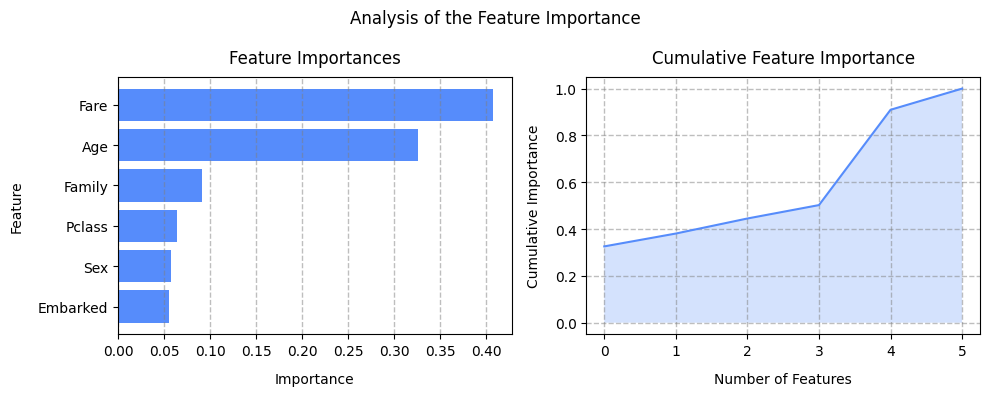

In [14]:
# Graphic results

import numpy as np
import matplotlib.pyplot as plt

# Input data
x_axis = np.arange(len(feature_importances_cum))

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.barh(importances_df["feature"], importances_df["importance"])
ax.invert_yaxis()
ax.grid(axis='x', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Feature Importances", pad=10, loc='center', color='black')
ax.set_xlabel("Importance", labelpad=10, loc='center', color='black')
ax.set_ylabel("Feature", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.plot(x_axis, feature_importances_cum)
ax.fill_between(x_axis, feature_importances_cum, alpha=0.25)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Cumulative Feature Importance", pad=10, loc='center', color='black')
ax.set_xlabel("Number of Features", labelpad=10, loc='center', color='black')
ax.set_ylabel("Cumulative Importance", labelpad=10, loc='center', color='black')

plt.suptitle(f"Analysis of the Feature Importance")

plt.tight_layout()
plt.show()

In [15]:
# CatBoost

import joblib
import apps.main as mn
from pathlib import Path
from catboost import CatBoostClassifier

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset_catboost_c.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = CatBoostClassifier(
        iterations=100,
        max_depth=5,
        learning_rate=0.05,
        random_state=rng_seed,
        verbose=False,
        thread_count=-1,
        allow_writing_files=False  # don't save logs
    )
    model.fit(X_train, Y_train, cat_features=col_cat_type)
    # save model
    joblib.dump(model, model_file_name)

Y_pred_catboost = model.predict(X_test)
Y_prob_catboost = model.predict_proba(X_test)[:, 1]

# Print results
display(Markdown(f"### CatBoost"))
df_catboost_c = mn.calc_class_metrics(Y_test, Y_pred_catboost, Y_prob_catboost)


### CatBoost

Attribute,Result
Confusion Matrix,[[102 8] [ 27 42]]
Accuracy (Точність),0.8045
Precision (Влучність),0.8400
Recall (Повнота),0.6087
F1-score,0.7059
Receiver Operating Characteristic (ROC-AUC),0.8572
Average Precision (AP),0.8427


              precision    recall  f1-score   support

           0       0.79      0.93      0.85       110
           1       0.84      0.61      0.71        69

    accuracy                           0.80       179
   macro avg       0.82      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



In [16]:
import numpy as np
import pandas as pd

# Input data

# Solution
features = X_data.columns
feature_importances = model.feature_importances_ / model.feature_importances_.sum()
feature_importances_cum = np.cumsum(feature_importances)

importances_df = (pd.DataFrame({"feature": features, "importance": feature_importances}).
                  sort_values(by="importance", ascending=False, ignore_index=True))

# Print results
display(importances_df.style.set_caption("Feature Importances"))

,feature,importance
0,Sex,0.597961
1,Pclass,0.158399
2,Age,0.085512
3,Fare,0.077099
4,Family,0.047339
5,Embarked,0.033690


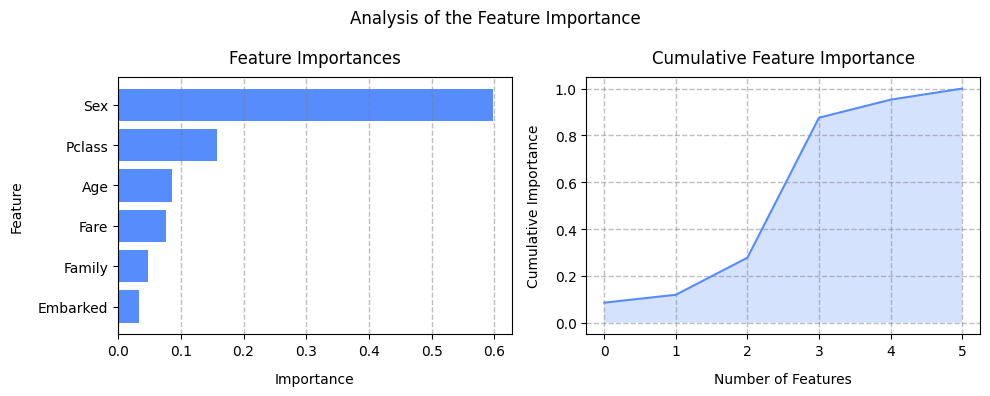

In [17]:
# Graphic results

import numpy as np
import matplotlib.pyplot as plt

# Input data
x_axis = np.arange(len(feature_importances_cum))

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.barh(importances_df["feature"], importances_df["importance"])
ax.invert_yaxis()
ax.grid(axis='x', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Feature Importances", pad=10, loc='center', color='black')
ax.set_xlabel("Importance", labelpad=10, loc='center', color='black')
ax.set_ylabel("Feature", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.plot(x_axis, feature_importances_cum)
ax.fill_between(x_axis, feature_importances_cum, alpha=0.25)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Cumulative Feature Importance", pad=10, loc='center', color='black')
ax.set_xlabel("Number of Features", labelpad=10, loc='center', color='black')
ax.set_ylabel("Cumulative Importance", labelpad=10, loc='center', color='black')

plt.suptitle(f"Analysis of the Feature Importance")

plt.tight_layout()
plt.show()

In [18]:
# Comparing models

from apps.reporter import Reporter

# Input data
models = [
    ("XGBoost", df_xgboost_c),
    ("LightGBM", df_lightgbm_c),
    ("CatBoost", df_catboost_c),
]

# Solution

# Print results
Reporter.print_concat_pd_reports(models, "Порівняння результатів моделей")


,Confusion Matrix,Accuracy (Точність),Precision (Влучність),Recall (Повнота),F1-score,Receiver Operating Characteristic (ROC-AUC),Average Precision (AP)
XGBoost,[[99 11] [24 45]],0.8045,0.8036,0.6522,0.7200,0.8394,0.8179
LightGBM,[[96 14] [25 44]],0.7821,0.7586,0.6377,0.6929,0.8246,0.7955
CatBoost,[[102 8] [ 27 42]],0.8045,0.8400,0.6087,0.7059,0.8572,0.8427


Із документації для "Confusion Matrix":

Колонка 1 | Колонка 2
--- | ---
true negatives :math:`C_{0,0}` | false positives :math:`C_{0,1}`
false negatives :math:`C_{1,0}` | true positives :math:`C_{1,1}`

Матриця:

№1 | №2
--|--
TN | FP
FN | TP

* TN — фактично/реально 0, передбачено/вгадано 0; (Правильно вказана смерть)
* FP — фактично/реально 0, передбачено/вгадано 1; (Хибна надія на виживання)
* FN — фактично/реально 1, передбачено/вгадано 0; (Помилково вказана смерть)
* TP — фактично/реально 1, передбачено/вгадано 1; (Правильно сповіщено про те що вижив)

- Accuracy (Точність) `[(TP + TN)/(Total)]`: Загальний відсоток правильних відповідей.
- Precision (Влучність) `[TP/(TP + FP)]`: Наскільки ми можемо довіряти моделі, коли вона каже "вижив".
- Recall (Повнота) `[TP/(TP + FN)]`: Який відсоток усіх, хто вижив, ми реально знайшли.

Висновок. Серед лідерів можна виділити XGBoost і CatBoost, а щоб обрати найкращу модель, то необхідно визначити, які метрики для дослідження є важливішими. CatBoost має найвищі результати в Precision, ROC-AUC та Average Precision, тобто найкраще показує пасажирів за ймовірністю виживання та робить найменше помилок. XGBoost має найвищі результати в Recall та F1-score, тобто найкраще показує пасажирів, які вижили. Точність Accuracy для цих моделей середня, оскільки це значення трохи більше від того, якби всі значення поставили нулі. Найзручніші моделі в роботі з категоріальними змінними — це LightGBM і CatBoost.

Найважливіші ознаки:
- для XGBoost — Sex і Pclass;
- для LightGBM — Fare і Age;
- для CatBoost — Sex і Pclass;

Збіг з інтуїцією:
- Sex — збігається із XGBoost і CatBoost;
- Pclass — збігається із XGBoost і CatBoost;
- Age — збігається із CatBoost;
- Fare — збігається із CatBoost;

**Grid Search CV**

In [19]:
# XGBoost

import apps.main as mn
import apps.reporter as rpt
from xgboost import XGBClassifier
from sklearn.model_selection import KFold, GridSearchCV

# Input data
rng_seed = 42
n_splits = 3
load_model = False
model_file_name = "resources/titanic-dataset_grid_xgboost_c.model"
file_path = Path(model_file_name)

accuracy_name = "accuracy"
precision_name = "precision"
recall_name = "recall"
f1_name = "f1"
scorings = {
    'accuracy': accuracy_name,
    'precision': precision_name,
    'recall': recall_name,
    'f1': f1_name,
}
grid_params = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
}

# Solution
# try to load model
if load_model and file_path.exists():
    grid_search = joblib.load(model_file_name)
else:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)
    grid_model = XGBClassifier(learning_rate=0.05, random_state=rng_seed, eval_metric='logloss')
    grid_search = GridSearchCV(grid_model,
                               grid_params,
                               cv=kf,
                               scoring=scorings,
                               refit=f1_name,
                               n_jobs=-1)
    grid_search.fit(X_train_ohe, Y_train_ohe, verbose=0)
    # save model
    joblib.dump(grid_search, model_file_name)

# scores = grid_search.cv_results_

best_grid_model = grid_search.best_estimator_
Y_pred_xgboost = best_grid_model.predict(X_test_ohe)

rp = rpt.Reporter()
rp.tolerance = 4
rp.add_item("Найкращі параметри", str(grid_search.best_params_))
rp.add_item("Найкраща оцінка за F1-score", rp.format_value(grid_search.best_score_))

# Print results
display(Markdown(f"### XGBoost"))
mn.calc_class_metrics(Y_test_ohe, Y_pred_xgboost)
rp.print_pd_report(f"Кращі результати (Grid Search)")

### XGBoost

Attribute,Result
Confusion Matrix,[[96 14] [23 46]]
Accuracy (Точність),0.7933
Precision (Влучність),0.7667
Recall (Повнота),0.6667
F1-score,0.7132


              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



Attribute,Result
Найкращі параметри,"{'max_depth': 5, 'n_estimators': 300}"
Найкраща оцінка за F1-score,0.7510


In [20]:
# LightGBM

import apps.main as mn
import apps.reporter as rpt
from lightgbm import LGBMClassifier
from sklearn.model_selection import KFold, GridSearchCV

# Input data
rng_seed = 42
n_splits = 3
load_model = False
model_file_name = "resources/titanic-dataset_grid_lightgbm_c.model"
file_path = Path(model_file_name)

accuracy_name = "accuracy"
precision_name = "precision"
recall_name = "recall"
f1_name = "f1"
scorings = {
    'accuracy': accuracy_name,
    'precision': precision_name,
    'recall': recall_name,
    'f1': f1_name,
}
grid_params = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
}

# Solution
# try to load model
if load_model and file_path.exists():
    grid_search = joblib.load(model_file_name)
else:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)
    grid_model = LGBMClassifier(learning_rate=0.05, random_state=rng_seed, verbose=-1)
    grid_search = GridSearchCV(grid_model,
                               grid_params,
                               cv=kf,
                               scoring=scorings,
                               refit=f1_name,
                               n_jobs=-1)
    grid_search.fit(X_train, Y_train, categorical_feature=col_cat_type)
    # save model
    joblib.dump(grid_search, model_file_name)

# scores = grid_search.cv_results_

best_grid_model = grid_search.best_estimator_
Y_pred_lightgbm = best_grid_model.predict(X_test)

rp = rpt.Reporter()
rp.tolerance = 4
rp.add_item("Найкращі параметри", str(grid_search.best_params_))
rp.add_item("Найкраща оцінка за F1-score", rp.format_value(grid_search.best_score_))

# Print results
display(Markdown(f"### LightGBM"))
mn.calc_class_metrics(Y_test, Y_pred_lightgbm)
rp.print_pd_report(f"Кращі результати (Grid Search)")

### LightGBM

Attribute,Result
Confusion Matrix,[[95 15] [27 42]]
Accuracy (Точність),0.7654
Precision (Влучність),0.7368
Recall (Повнота),0.6087
F1-score,0.6667


              precision    recall  f1-score   support

           0       0.78      0.86      0.82       110
           1       0.74      0.61      0.67        69

    accuracy                           0.77       179
   macro avg       0.76      0.74      0.74       179
weighted avg       0.76      0.77      0.76       179



Attribute,Result
Найкращі параметри,"{'max_depth': 20, 'n_estimators': 100}"
Найкраща оцінка за F1-score,0.7672


In [21]:
# CatBoost

import apps.main as mn
import apps.reporter as rpt
from catboost import CatBoostClassifier
from sklearn.model_selection import KFold, GridSearchCV

# Input data
rng_seed = 42
n_splits = 3
# TODO:
load_model = False
model_file_name = "resources/titanic-dataset_grid_catboost_c.model"
file_path = Path(model_file_name)

accuracy_name = "accuracy"
precision_name = "precision"
recall_name = "recall"
f1_name = "f1"
scorings = {
    'accuracy': accuracy_name,
    'precision': precision_name,
    'recall': recall_name,
    'f1': f1_name,
}
grid_params = {
    'iterations': [50, 100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
}

# Solution
# try to load model
if load_model and file_path.exists():
    grid_search = joblib.load(model_file_name)
else:
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=rng_seed)
    grid_model = CatBoostClassifier(learning_rate=0.05, random_state=rng_seed, verbose=False, allow_writing_files=False)
    grid_search = GridSearchCV(grid_model,
                               grid_params,
                               cv=kf,
                               scoring=scorings,
                               refit=f1_name,
                               n_jobs=-1)
    grid_search.fit(X_train, Y_train, cat_features=col_cat_type)
    # save model
    joblib.dump(grid_search, model_file_name)

# scores = grid_search.cv_results_

best_grid_model = grid_search.best_estimator_
Y_pred_catboost = best_grid_model.predict(X_test)

rp = rpt.Reporter()
rp.tolerance = 4
rp.add_item("Найкращі параметри", str(grid_search.best_params_))
rp.add_item("Найкраща оцінка за F1-score", rp.format_value(grid_search.best_score_))

# Print results
display(Markdown(f"### CatBoost"))
mn.calc_class_metrics(Y_test, Y_pred_catboost)
rp.print_pd_report(f"Кращі результати (Grid Search)")

/Users/bohdanpinchuk/Documents/Data Science/Development/Data_Science/Practical_tasks/Homework_14/DataScience-PBY_HW14/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/bohdanpinchuk/Documents/Data Science/Development/Data_Science/Practical_tasks/Homework_14/DataScience-PBY_HW14/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/bohdanpinchuk/Documents/D

### CatBoost

Attribute,Result
Confusion Matrix,[[104 6] [ 28 41]]
Accuracy (Точність),0.8101
Precision (Влучність),0.8723
Recall (Повнота),0.5942
F1-score,0.7069


              precision    recall  f1-score   support

           0       0.79      0.95      0.86       110
           1       0.87      0.59      0.71        69

    accuracy                           0.81       179
   macro avg       0.83      0.77      0.78       179
weighted avg       0.82      0.81      0.80       179



Attribute,Result
Найкращі параметри,"{'iterations': 100, 'max_depth': None}"
Найкраща оцінка за F1-score,0.7544


## ✅ Рішення 4
Використайте датасет Fish Market.

Попередня обробка:
- дослідити дані
- перевірити пропуски
- обробити категоріальну змінну `Species`

Для моделей:
- **XGBoost** → OneHotEncoding
- **LightGBM** → native categorical features
- **CatBoost** → native categorical features

Цільова змінна: `Weight`

In [22]:
# Data analysis

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.core.display import Markdown

# Input data
data_set = fish_market
n_columns = data_set.columns.size
n_rows = data_set.index.size

# Solution
columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Аналіз даних"))
rp.print_pd_report("Параметри таблиці до обробки")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))

display(data_set)

### Аналіз даних

Attribute,Result
Кількість рядків,159
Кількість об’єктів у датасеті,159
Кількість стовпців,7
Кількість числових ознак,6
Кількість категоріальних ознак,1
Пропущені значення,немає


,Types
Species,str
Weight,float64
Length1,float64
Length2,float64
Length3,float64
Height,float64
Width,float64


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242,23.2,25.4,30,11.52,4.02
1,Bream,290,24,26.3,31.2,12.48,4.3056
2,Bream,340,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363,26.3,29,33.5,12.73,4.4555
4,Bream,430,26.5,29,34,12.444,5.134
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.43,1.269
156,Smelt,12.2,12.1,13,13.8,2.277,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [23]:
# Data preparation

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.core.display import Markdown

# Input data
S_data = fish_market["Species"]

# Solution
data_set = fish_market
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Підготовка даних (fish_market)"))
rp.print_pd_report("Параметри таблиці без кодування")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

display(types_df.style.set_caption("Типи даних"))
display(data_set)

### Підготовка даних (fish_market)

Attribute,Result
Кількість рядків,159
Кількість об’єктів у датасеті,159
Кількість стовпців,7
Кількість числових ознак,6
Кількість категоріальних ознак,1
Пропущені значення,немає


,Types
Species,str
Weight,float64
Length1,float64
Length2,float64
Length3,float64
Height,float64
Width,float64


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242,23.2,25.4,30,11.52,4.02
1,Bream,290,24,26.3,31.2,12.48,4.3056
2,Bream,340,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363,26.3,29,33.5,12.73,4.4555
4,Bream,430,26.5,29,34,12.444,5.134
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.43,1.269
156,Smelt,12.2,12.1,13,13.8,2.277,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [24]:
# Data preparation

import numpy as np
import pandas as pd
import apps.reporter as rpt
from sklearn.preprocessing import OneHotEncoder
from IPython.core.display import Markdown

# Input data
cat_col_list = ["Species"]

# Solution
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_col_list),
], remainder="passthrough", verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")
transformed_data = preprocessor.fit_transform(fish_market)
fish_market_ohe = pd.DataFrame(transformed_data, columns=preprocessor.get_feature_names_out())

data_set = fish_market_ohe
n_columns = data_set.columns.size
n_rows = data_set.index.size

columns_df = pd.DataFrame(data_set.columns, columns=["Columns"])
types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number).columns
col_cat_type = data_set.select_dtypes(exclude=np.number).columns

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість об’єктів у датасеті", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Підготовка даних (fish_market_ohe)"))
rp.print_pd_report("Параметри таблиці з кодуванням")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))

display(types_df.style.set_caption("Типи даних"))
display(data_set)

### Підготовка даних (fish_market_ohe)

Attribute,Result
Кількість рядків,159
Кількість об’єктів у датасеті,159
Кількість стовпців,13
Кількість числових ознак,13
Кількість категоріальних ознак,0
Пропущені значення,немає


,Types
Species_Bream,float64
Species_Parkki,float64
Species_Perch,float64
Species_Pike,float64
Species_Roach,float64
Species_Smelt,float64
Species_Whitefish,float64
Weight,float64
Length1,float64
Length2,float64


,Species_Bream,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish,Weight,Length1,Length2,Length3,Height,Width
0,1,0,0,0,0,0,0,242,23.2,25.4,30,11.52,4.02
1,1,0,0,0,0,0,0,290,24,26.3,31.2,12.48,4.3056
2,1,0,0,0,0,0,0,340,23.9,26.5,31.1,12.3778,4.6961
3,1,0,0,0,0,0,0,363,26.3,29,33.5,12.73,4.4555
4,1,0,0,0,0,0,0,430,26.5,29,34,12.444,5.134
...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,0,0,0,0,0,1,0,12.2,11.5,12.2,13.4,2.0904,1.3936
155,0,0,0,0,0,1,0,13.4,11.7,12.4,13.5,2.43,1.269
156,0,0,0,0,0,1,0,12.2,12.1,13,13.8,2.277,1.2558
157,0,0,0,0,0,1,0,19.7,13.2,14.3,15.2,2.8728,2.0672


In [25]:
# Splitting data

import gc
import pandas as pd
from sklearn.model_selection import train_test_split

# Input data
target_value = "Weight"
test_ratio = 0.2
rng_seed = 42

# Solution
X_data_ohe = fish_market_ohe.drop(columns=[target_value])
Y_data_ohe = fish_market_ohe[target_value]
X_data = fish_market.drop(columns=[target_value])
Y_data = fish_market[target_value]

col_cat_type = X_data.select_dtypes(exclude=np.number).columns.tolist()
for col_name in col_cat_type:
    X_data[col_name] = X_data[col_name].astype('category')

cat_type_df = X_data[col_cat_type]

del fish_market, fish_market_ohe

X_train, X_test, Y_train, Y_test = train_test_split(X_data, Y_data,
                                                    test_size=test_ratio,
                                                    stratify=S_data,
                                                    random_state=rng_seed,
                                                    shuffle=True)

X_train_ohe, X_test_ohe, Y_train_ohe, Y_test_ohe = train_test_split(X_data_ohe, Y_data_ohe,
                                                                    test_size=test_ratio,
                                                                    stratify=S_data,
                                                                    random_state=rng_seed,
                                                                    shuffle=True)

S_train = S_data.loc[X_train.index]
S_test = S_data.loc[X_test.index]

# Print results
display(Markdown(f"### Розбиття даних"))

display(cat_type_df.describe().T.style.set_caption("Статистика для категоріальних змінних"))

for col_name in col_cat_type:
    display(pd.concat([
        cat_type_df[col_name].value_counts(),
        cat_type_df[col_name].value_counts(normalize=True)
    ], axis=1).style.set_caption(f"Категорія: \"{col_name}\""))

display(Markdown(f"**Датасети: (fish_market/fish_market_ohe)**"))
display(pd.concat([
    S_train.value_counts(),
    S_train.value_counts(normalize=True)
], axis=1).style.set_caption("Вибірка для навчання"))
display(pd.concat([
    S_test.value_counts(),
    S_test.value_counts(normalize=True)
], axis=1).style.set_caption("Вибірка для тестування"))

# Clean
_ = gc.collect()

### Розбиття даних

,count,unique,top,freq
Species,159,7,Perch,56


,count,proportion
Species,,
Perch,56,0.352201
Bream,35,0.220126
Roach,20,0.125786
Pike,17,0.106918
Smelt,14,0.088050
Parkki,11,0.069182
Whitefish,6,0.037736


**Датасети: (fish_market/fish_market_ohe)**

,count,proportion
Species,,
Perch,45,0.354331
Bream,28,0.220472
Roach,16,0.125984
Pike,13,0.102362
Smelt,11,0.086614
Parkki,9,0.070866
Whitefish,5,0.039370


,count,proportion
Species,,
Perch,11,0.343750
Bream,7,0.218750
Roach,4,0.125000
Pike,4,0.125000
Smelt,3,0.093750
Parkki,2,0.062500
Whitefish,1,0.031250


## ✅ Рішення 5-6

Побудуйте:

- `XGBRegressor`
- `LGBMRegressor`
- `CatBoostRegressor`

Для кожної моделі:
- натренуйте модель
- зробіть прогноз
- обчисліть метрики:
  - MAE
  - MSE
  - RMSE
  - R²

---

Порівняйте результати моделей

Створіть таблицю такого формату:

| Model | MAE | MSE | RMSE | R² |
|--------|------|------|------|------|
| XGBoost | ? | ? | ? | ? |
| LightGBM | ? | ? | ? | ? |
| CatBoost | ? | ? | ? | ? |

---

Проаналізуйте:
- яка модель працює найкраще
- чи вплинула обробка категоріальних змінних на результат
- яка модель найпростіша у використанні

---

Для кожної моделі:

- отримайте feature importance
- побудуйте графіки

Проаналізуйте:
- які характеристики риби найбільше впливають на вагу:
  - `Length`
  - `Height`
  - `Width`
  - `Species`

In [26]:
# XGBoost

import joblib
import apps.main as mn
from pathlib import Path
from xgboost import XGBRegressor

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset_xgboost_r.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.05,
        random_state=rng_seed,
        n_jobs=-1
    )
    model.fit(X_train_ohe, Y_train_ohe, verbose=0)
    # save model
    joblib.dump(model, model_file_name)

Y_pred_xgboost = model.predict(X_test_ohe)

# Print results
display(Markdown(f"### XGBoost"))
df_xgboost_r = mn.calc_regres_metrics(Y_test_ohe, Y_pred_xgboost)


### XGBoost

Attribute,Result
MAE,44.9103
MSE,4171.5524
RMSE,64.5876
R² (коефіцієнт детермінації),0.9779


In [27]:
import numpy as np
import pandas as pd

# Input data

# Solution
features = X_data_ohe.columns
feature_importances = model.feature_importances_ / model.feature_importances_.sum()
feature_importances_cum = np.cumsum(feature_importances)

importances_df = (pd.DataFrame({"feature": features, "importance": feature_importances}).
                  sort_values(by="importance", ascending=False, ignore_index=True))

# Print results
display(importances_df.style.set_caption("Feature Importances"))

,feature,importance
0,Width,0.683123
1,Length3,0.224611
2,Length2,0.041169
3,Length1,0.026443
4,Species_Roach,0.009422
5,Species_Perch,0.007574
6,Height,0.006015
7,Species_Pike,0.000708
8,Species_Bream,0.000456
9,Species_Parkki,0.000301


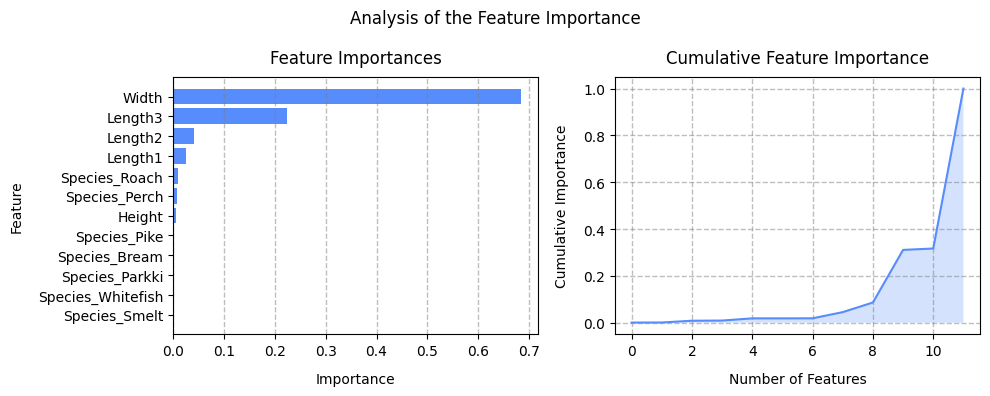

In [28]:
# Graphic results

import numpy as np
import matplotlib.pyplot as plt

# Input data
x_axis = np.arange(len(feature_importances_cum))

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.barh(importances_df["feature"], importances_df["importance"])
ax.invert_yaxis()
ax.grid(axis='x', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Feature Importances", pad=10, loc='center', color='black')
ax.set_xlabel("Importance", labelpad=10, loc='center', color='black')
ax.set_ylabel("Feature", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.plot(x_axis, feature_importances_cum)
ax.fill_between(x_axis, feature_importances_cum, alpha=0.25)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Cumulative Feature Importance", pad=10, loc='center', color='black')
ax.set_xlabel("Number of Features", labelpad=10, loc='center', color='black')
ax.set_ylabel("Cumulative Importance", labelpad=10, loc='center', color='black')

plt.suptitle(f"Analysis of the Feature Importance")

plt.tight_layout()
plt.show()

In [29]:
# LightGBM

import joblib
import apps.main as mn
from pathlib import Path
from lightgbm import LGBMRegressor

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset_lightgbm_r.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = LGBMRegressor(
        n_estimators=100,
        learning_rate=0.05,
        random_state=rng_seed,
        verbose=-1,
        n_jobs=-1
    )
    model.fit(X_train, Y_train, categorical_feature=col_cat_type)
    # save model
    joblib.dump(model, model_file_name)

Y_pred_lightgbm = model.predict(X_test)

# Print results
display(Markdown(f"### LightGBM"))
df_lightgbm_r = mn.calc_regres_metrics(Y_test, Y_pred_lightgbm)


### LightGBM

Attribute,Result
MAE,71.3404
MSE,27696.7355
RMSE,166.4234
R² (коефіцієнт детермінації),0.8530


In [30]:
import numpy as np
import pandas as pd

# Input data

# Solution
features = X_data.columns
feature_importances = model.feature_importances_ / model.feature_importances_.sum()
feature_importances_cum = np.cumsum(feature_importances)

importances_df = (pd.DataFrame({"feature": features, "importance": feature_importances}).
                  sort_values(by="importance", ascending=False, ignore_index=True))

# Print results
display(importances_df.style.set_caption("Feature Importances"))

,feature,importance
0,Width,0.307500
1,Height,0.277500
2,Length3,0.190000
3,Length1,0.167500
4,Length2,0.057500
5,Species,0.000000


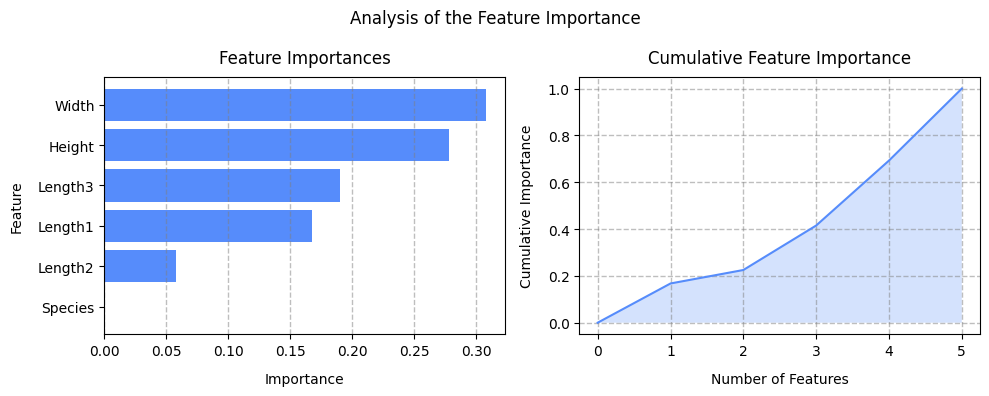

In [31]:
# Graphic results

import numpy as np
import matplotlib.pyplot as plt

# Input data
x_axis = np.arange(len(feature_importances_cum))

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.barh(importances_df["feature"], importances_df["importance"])
ax.invert_yaxis()
ax.grid(axis='x', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Feature Importances", pad=10, loc='center', color='black')
ax.set_xlabel("Importance", labelpad=10, loc='center', color='black')
ax.set_ylabel("Feature", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.plot(x_axis, feature_importances_cum)
ax.fill_between(x_axis, feature_importances_cum, alpha=0.25)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Cumulative Feature Importance", pad=10, loc='center', color='black')
ax.set_xlabel("Number of Features", labelpad=10, loc='center', color='black')
ax.set_ylabel("Cumulative Importance", labelpad=10, loc='center', color='black')

plt.suptitle(f"Analysis of the Feature Importance")

plt.tight_layout()
plt.show()

In [32]:
# CatBoost

import joblib
import apps.main as mn
from pathlib import Path
from catboost import CatBoostRegressor

# Input data
rng_seed = 42
load_model = True
model_file_name = "resources/titanic-dataset_catboost_r.model"

# Solution
file_path = Path(model_file_name)

# try to load model
if load_model and file_path.exists():
    model = joblib.load(model_file_name)
else:
    model = CatBoostRegressor(
        iterations=100,
        max_depth=5,
        learning_rate=0.05,
        random_state=rng_seed,
        verbose=False,
        thread_count=-1,
        allow_writing_files=False  # don't save logs
    )
    model.fit(X_train, Y_train, cat_features=col_cat_type)
    # save model
    joblib.dump(model, model_file_name)

Y_pred_catboost = model.predict(X_test)

# Print results
display(Markdown(f"### CatBoost"))
df_catboost_r = mn.calc_regres_metrics(Y_test, Y_pred_catboost)


### CatBoost

Attribute,Result
MAE,52.9030
MSE,12420.0956
RMSE,111.4455
R² (коефіцієнт детермінації),0.9341


In [33]:
import numpy as np
import pandas as pd

# Input data

# Solution
features = X_data.columns
feature_importances = model.feature_importances_ / model.feature_importances_.sum()
feature_importances_cum = np.cumsum(feature_importances)

importances_df = (pd.DataFrame({"feature": features, "importance": feature_importances}).
                  sort_values(by="importance", ascending=False, ignore_index=True))

# Print results
display(importances_df.style.set_caption("Feature Importances"))

,feature,importance
0,Width,0.332759
1,Height,0.199492
2,Length3,0.165129
3,Length2,0.152242
4,Length1,0.150378
5,Species,0.000000


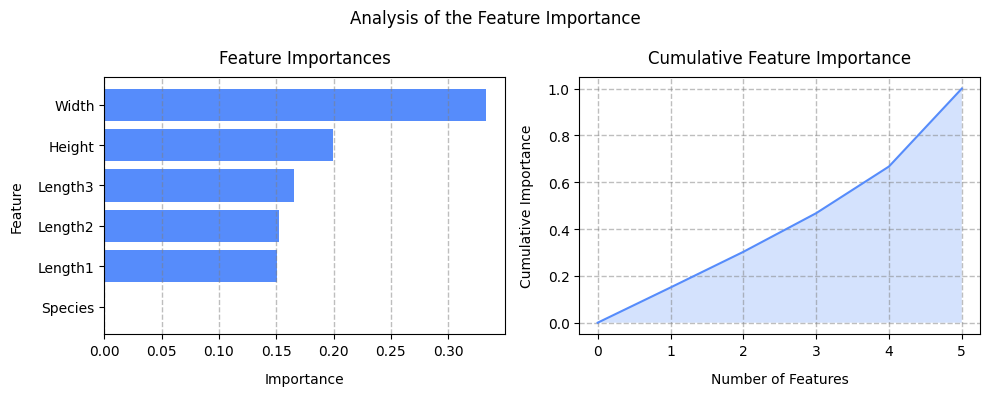

In [34]:
# Graphic results

import numpy as np
import matplotlib.pyplot as plt

# Input data
x_axis = np.arange(len(feature_importances_cum))

# Solution
_, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.barh(importances_df["feature"], importances_df["importance"])
ax.invert_yaxis()
ax.grid(axis='x', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Feature Importances", pad=10, loc='center', color='black')
ax.set_xlabel("Importance", labelpad=10, loc='center', color='black')
ax.set_ylabel("Feature", labelpad=10, loc='center', color='black')

ax = axes[1]
ax.plot(x_axis, feature_importances_cum)
ax.fill_between(x_axis, feature_importances_cum, alpha=0.25)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Cumulative Feature Importance", pad=10, loc='center', color='black')
ax.set_xlabel("Number of Features", labelpad=10, loc='center', color='black')
ax.set_ylabel("Cumulative Importance", labelpad=10, loc='center', color='black')

plt.suptitle(f"Analysis of the Feature Importance")

plt.tight_layout()
plt.show()

In [35]:
# Comparing models

from apps.reporter import Reporter

# Input data
models = [
    ("XGBoost", df_xgboost_r),
    ("LightGBM", df_lightgbm_r),
    ("CatBoost", df_catboost_r),
]

# Solution

# Print results
Reporter.print_concat_pd_reports(models, "Порівняння результатів моделей")


,MAE,MSE,RMSE,R² (коефіцієнт детермінації)
XGBoost,44.9103,4171.5524,64.5876,0.9779
LightGBM,71.3404,27696.7355,166.4234,0.8530
CatBoost,52.9030,12420.0956,111.4455,0.9341


Висновок. Серед лідерів можна виділити XGBoost, а CatBoost на другому місці. XGBoost має найкращі результати по всіх метриках. Обробка категоріальних даних мала б уплинути на результат, але й ручна обробка показала себе доволі добре для XGBoost, можливо, причиною є малий розмір даних. Найзручніші моделі в роботі з категоріальними змінними — це LightGBM і CatBoost.

Ознаки, що найбільше впливають на вагу риби:
- для XGBoost — Width і Length;
- для LightGBM — Width, Height і Length;
- для CatBoost — Width, Height і Length;
